<a href="https://colab.research.google.com/github/mohammadhadiGhadam/Machine_Learning_2024/blob/main/Miniproject3_ghadam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**mini project 3**
/mohammad hadi ghadam

## Question 1

**Part 1**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.6/549.6 kB 6.7 MB/s eta 0:00:00


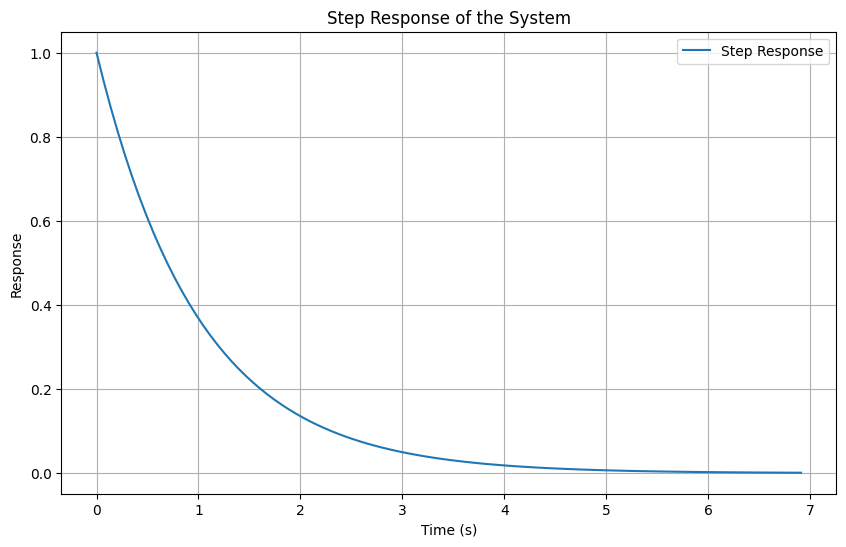

Tuned PID Parameters:
Kp: 4.8, Ki: 4.8, Kd: 1.2


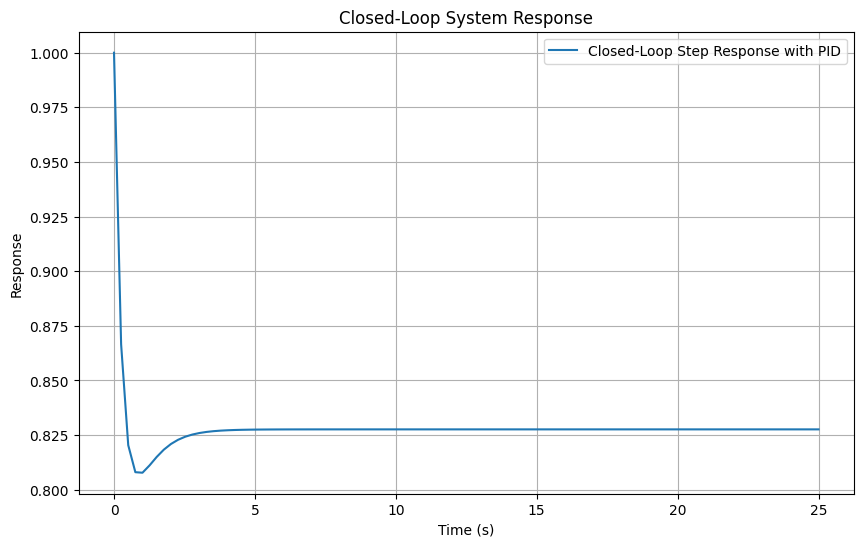

In [ ]:
!pip install control
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# Define the transfer function of the system
numerator = [1, 0]  # s
denominator = [1, 1]  # s+1
system = ctrl.TransferFunction(numerator, denominator)

# Step response to find K_u and P_u (approximation)
time, response = ctrl.step_response(system)

# Plot the step response
plt.figure(figsize=(10, 6))
plt.plot(time, response, label='Step Response')
plt.title('Step Response of the System')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.grid()
plt.legend()
plt.show()

# Ziegler-Nichols Tuning Rules (Example K_u and P_u)
Ku = 8  # Example Ultimate Gain (find through simulation or trials)
Pu = 2  # Example Ultimate Period

# Compute PID parameters using Ziegler-Nichols
Kp = 0.6 * Ku
Ki = 1.2 * Ku / Pu
Kd = 0.075 * Ku * Pu

print(f"Tuned PID Parameters:\nKp: {Kp}, Ki: {Ki}, Kd: {Kd}")

# Define the PID controller
pid = ctrl.TransferFunction([Kd, Kp, Ki], [1, 0])

# Closed-loop system with PID controller
closed_loop = ctrl.feedback(pid * system)

# Simulate the closed-loop step response
time, response = ctrl.step_response(closed_loop)

# Plot the closed-loop step response
plt.figure(figsize=(10, 6))
plt.plot(time, response, label='Closed-Loop Step Response with PID')
plt.title('Closed-Loop System Response')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.grid()
plt.legend()
plt.show()


**Part 2**

* Add delay

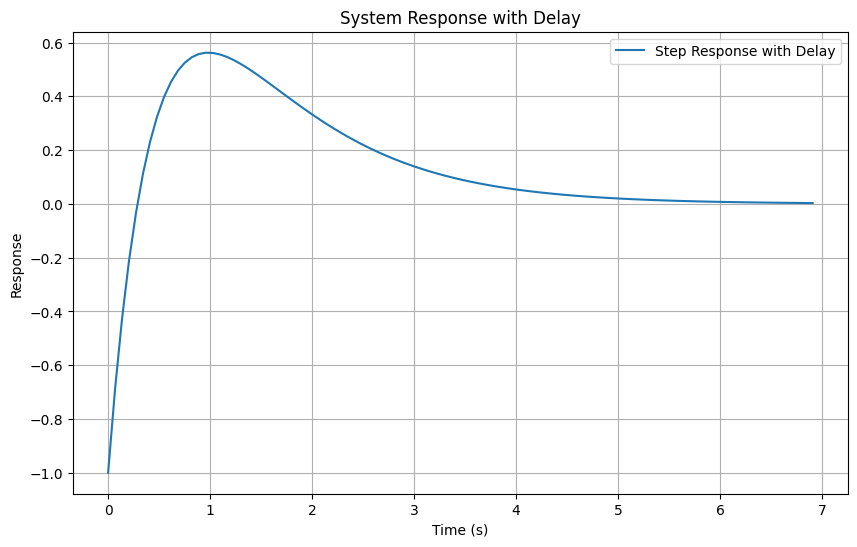

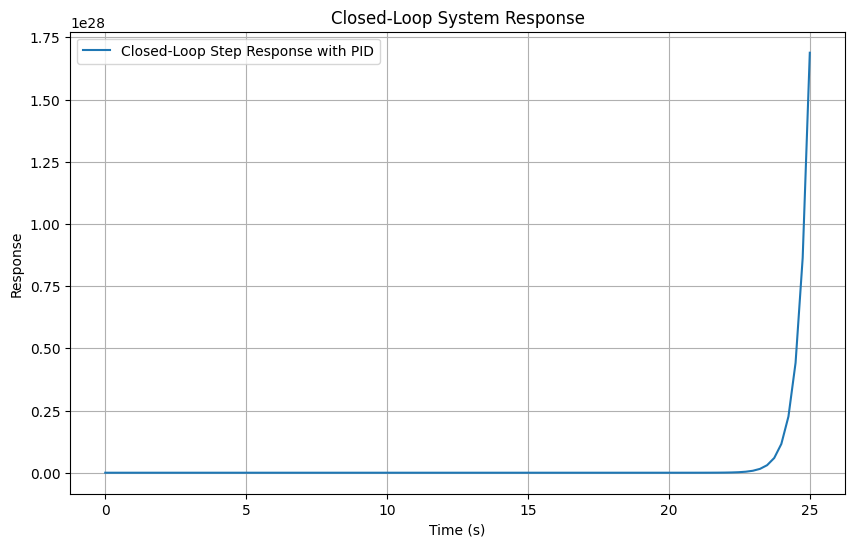

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# Original system: T(s) = s / (s + 1)
numerator = [1, 0]
denominator = [1, 1]
system = ctrl.TransferFunction(numerator, denominator)

# Add delay using Pade approximation
delay_time = 1  # Delay time (T)
num_delay, den_delay = ctrl.pade(delay_time, 1)  # First-order Pade approximation
delay = ctrl.TransferFunction(num_delay, den_delay)

# Combine system with delay
system_with_delay = system * delay

# Step response of system with delay
time, response = ctrl.step_response(system_with_delay)

# Plot the step response with delay
plt.figure(figsize=(10, 6))
plt.plot(time, response, label='Step Response with Delay')
plt.title('System Response with Delay')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.grid()
plt.legend()
plt.show()

# Closed-loop system with PID controller and delay
closed_loop = ctrl.feedback(pid * system_with_delay)

# Simulate the closed-loop step response
time, response = ctrl.step_response(closed_loop)

# Plot the closed-loop step response
plt.figure(figsize=(10, 6))
plt.plot(time, response, label='Closed-Loop Step Response with PID')
plt.title('Closed-Loop System Response')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.grid()
plt.legend()
plt.show()


IMC-Tuned PID Parameters:
Kp: 0.2625, Ki: 0.9523809523809523, Kd: 0.047619047619047616


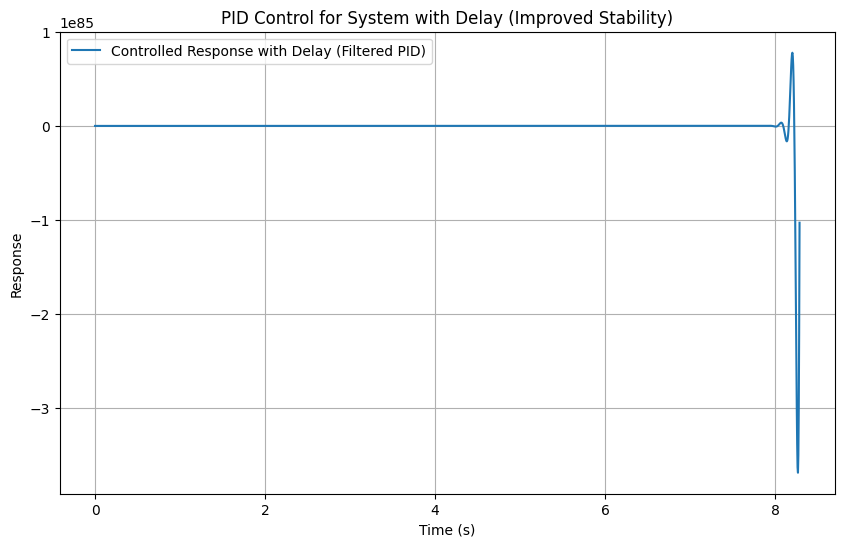

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# Define the original system
numerator = [1, 0]  # s
denominator = [1, 1]  # s+1
system = ctrl.TransferFunction(numerator, denominator)

# Add delay using second-order Pade approximation
delay_time = 0.1  # Delay time (T)
num_delay, den_delay = ctrl.pade(delay_time, 2)  # Second-order Pade approximation
delay = ctrl.TransferFunction(num_delay, den_delay)
system_with_delay = system * delay

# IMC-based tuning parameters for delay system
tau_c = 4  # Larger time constant for robustness
theta = delay_time  # Delay time
tau = 1  # Process time constant (from system dynamics)

# Compute IMC PID parameters
Kp_imc = (tau + theta / 2) / tau_c
Ki_imc = 1 / (tau + theta / 2)
Kd_imc = tau * theta / (2 * (tau + theta / 2))

print(f"IMC-Tuned PID Parameters:\nKp: {Kp_imc}, Ki: {Ki_imc}, Kd: {Kd_imc}")

# Define the PID controller with a low-pass filter
filter_coeff = 5  # Less aggressive filtering
pid_imc_filtered = ctrl.TransferFunction([Kd_imc, Kp_imc, Ki_imc], [1, filter_coeff])

# Closed-loop system with filtered PID
closed_loop_imc_filtered = ctrl.feedback(pid_imc_filtered * system_with_delay)

# Step response
time, response = ctrl.step_response(closed_loop_imc_filtered)

# Plot response
plt.figure(figsize=(10, 6))
plt.plot(time, response, label='Controlled Response with Delay (Filtered PID)')
plt.title('PID Control for System with Delay (Improved Stability)')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.grid()
plt.legend()
plt.show()


* Add noise

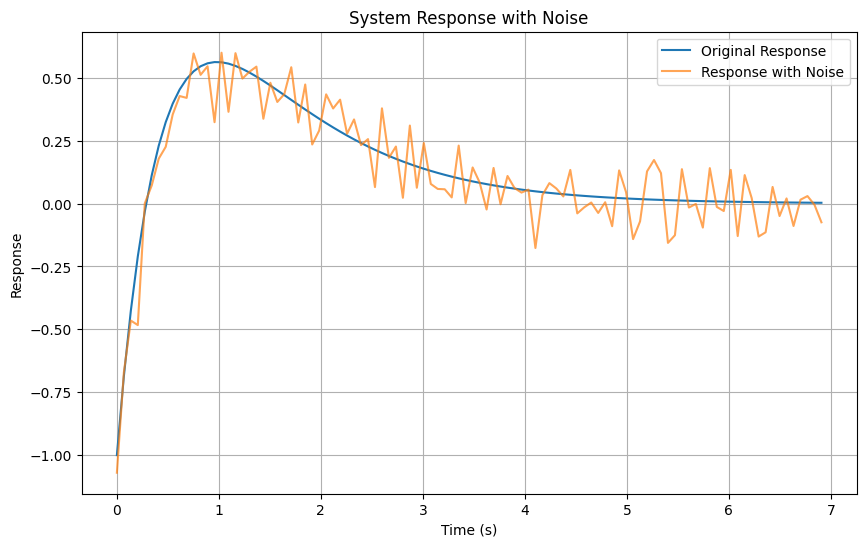

ControlMIMONotImplemented: TransferFunction.feedback is currently not implemented for MIMO systems.

In [ ]:
# Step response with added noise
time, response = ctrl.step_response(system_with_delay)
noise = 0.1 * np.random.normal(size=len(response))  # Add random Gaussian noise
response_with_noise = response + noise

# Plot the noisy response
plt.figure(figsize=(10, 6))
plt.plot(time, response, label='Original Response')
plt.plot(time, response_with_noise, label='Response with Noise', alpha=0.7)
plt.title('System Response with Noise')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.grid()
plt.legend()
plt.show()

# Closed-loop system with PID controller and delay
closed_loop = ctrl.feedback(pid * response_with_noise)

# Simulate the closed-loop step response
time, response = ctrl.step_response(closed_loop)

# Plot the closed-loop step response
plt.figure(figsize=(10, 6))
plt.plot(time, response, label='Closed-Loop Step Response with PID')
plt.title('Closed-Loop System Response')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.grid()
plt.legend()
plt.show()


* Add Disturbance

In [ ]:
# Disturbance added to the system
disturbance = 0.5 * np.sin(0.5 * time)  # Sinusoidal disturbance
response_with_disturbance = response_with_noise + disturbance

# Plot the response with disturbance
plt.figure(figsize=(10, 6))
plt.plot(time, response, label='Original Response')
plt.plot(time, response_with_disturbance, label='Response with Disturbance', alpha=0.7)
plt.title('System Response with Disturbance')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.grid()
plt.legend()
plt.show()

# Closed-loop system with PID controller and delay
closed_loop = ctrl.feedback(pid * response_with_disturbance)

# Simulate the closed-loop step response
time, response = ctrl.step_response(closed_loop)

# Plot the closed-loop step response
plt.figure(figsize=(10, 6))
plt.plot(time, response, label='Closed-Loop Step Response with PID')
plt.title('Closed-Loop System Response')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.grid()
plt.legend()
plt.show()

## Question 2

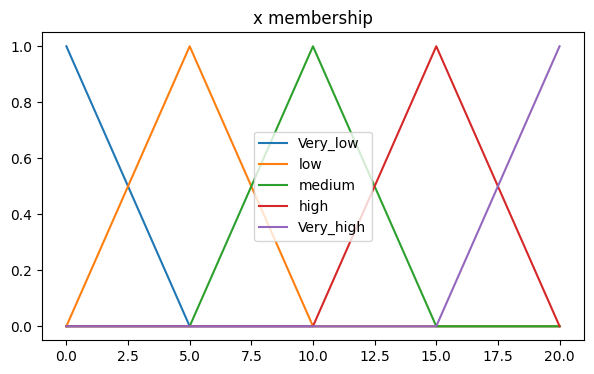

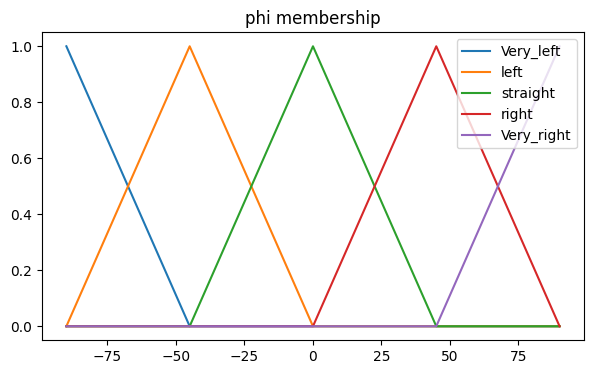

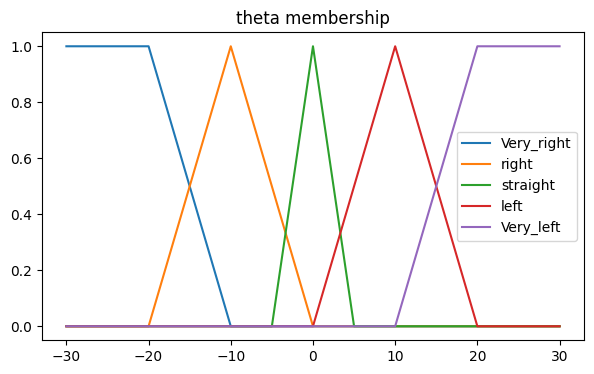

In [ ]:
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

#
# 1) Define two fuzzy input variables (x, phi) and one fuzzy output (theta).
#

# x: 0..20
x = ctrl.Antecedent(np.arange(0, 20.1, 0.5), 'x')

# phi: -90..+90
phi = ctrl.Antecedent(np.arange(-90, 91, 1), 'phi')

# theta: -30..+30  (Steering angle)
theta = ctrl.Consequent(np.arange(-30, 31, 1), 'theta')

###############################################################################
# 2) Define 5 membership functions for x, phi, and the output theta
###############################################################################

# --- x membership sets (0..20) ---
x['Very_low']  = fuzz.trapmf(x.universe, [0,  0,  0,   5])
x['low']       = fuzz.trimf(x.universe,  [0,  5,  10])
x['medium']    = fuzz.trimf(x.universe,  [5, 10,  15])
x['high']      = fuzz.trimf(x.universe,  [10, 15, 20])
x['Very_high'] = fuzz.trapmf(x.universe, [15, 20, 20,  20])

# --- phi membership sets (-90..+90) ---
phi['Very_left']  = fuzz.trapmf(phi.universe, [-90, -90, -90, -45])
phi['left']       = fuzz.trimf(phi.universe,  [-90, -45,   0])
phi['straight']   = fuzz.trimf(phi.universe,  [-45,   0,  45])
phi['right']      = fuzz.trimf(phi.universe,  [  0,  45,  90])
phi['Very_right'] = fuzz.trapmf(phi.universe, [ 45,  90,  90,  90])

# --- theta membership sets (output: -30..+30) ---
theta['Very_right']  = fuzz.trapmf(theta.universe, [-30, -30, -20, -10])
theta['right']       = fuzz.trimf(theta.universe,  [-20, -10,   0])
theta['straight']    = fuzz.trimf(theta.universe,  [ -5,   0,   5])
theta['left']        = fuzz.trimf(theta.universe,  [  0,  10,  20])
theta['Very_left']   = fuzz.trapmf(theta.universe, [ 10,  20,  30,  30])

###############################################################################
# 3) Define 25 rules to guide the car toward x ~ 10, phi ~ +90
###############################################################################

rules = []

# 1) x = Very_low
rules.append(ctrl.Rule(x['Very_low'] & phi['Very_left'],   theta['left']))
rules.append(ctrl.Rule(x['Very_low'] & phi['left'],        theta['left']))
rules.append(ctrl.Rule(x['Very_low'] & phi['straight'],    theta['left']))
rules.append(ctrl.Rule(x['Very_low'] & phi['right'],       theta['left']))
rules.append(ctrl.Rule(x['Very_low'] & phi['Very_right'],  theta['straight']))

# 2) x = low
rules.append(ctrl.Rule(x['low'] & phi['Very_left'],    theta['left']))
rules.append(ctrl.Rule(x['low'] & phi['left'],         theta['left']))
rules.append(ctrl.Rule(x['low'] & phi['straight'],     theta['left']))
rules.append(ctrl.Rule(x['low'] & phi['right'],        theta['left']))
rules.append(ctrl.Rule(x['low'] & phi['Very_right'],   theta['straight']))

# 3) x = medium
rules.append(ctrl.Rule(x['medium'] & phi['Very_left'],   theta['left']))
rules.append(ctrl.Rule(x['medium'] & phi['left'],        theta['left']))
rules.append(ctrl.Rule(x['medium'] & phi['straight'],    theta['straight']))
rules.append(ctrl.Rule(x['medium'] & phi['right'],       theta['straight']))
rules.append(ctrl.Rule(x['medium'] & phi['Very_right'],  theta['straight']))

# 4) x = high
rules.append(ctrl.Rule(x['high'] & phi['Very_left'],    theta['right']))
rules.append(ctrl.Rule(x['high'] & phi['left'],         theta['right']))
rules.append(ctrl.Rule(x['high'] & phi['straight'],     theta['right']))
rules.append(ctrl.Rule(x['high'] & phi['right'],        theta['right']))
rules.append(ctrl.Rule(x['high'] & phi['Very_right'],   theta['straight']))

# 5) x = Very_high
rules.append(ctrl.Rule(x['Very_high'] & phi['Very_left'],   theta['right']))
rules.append(ctrl.Rule(x['Very_high'] & phi['left'],        theta['right']))
rules.append(ctrl.Rule(x['Very_high'] & phi['straight'],    theta['right']))
rules.append(ctrl.Rule(x['Very_high'] & phi['right'],       theta['right']))
rules.append(ctrl.Rule(x['Very_high'] & phi['Very_right'],  theta['straight']))

###############################################################################
# 4) Build the ControlSystem & Simulation
###############################################################################
steering_ctrl = ctrl.ControlSystem(rules)
steering_sim = ctrl.ControlSystemSimulation(steering_ctrl)


###############################################################################
# 5) Plot membership functions
###############################################################################
plt.figure(figsize=(7,4))
for term in x.terms:
    plt.plot(x.universe, x[term].mf, label=term)
plt.title("x membership")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
for term in phi.terms:
    plt.plot(phi.universe, phi[term].mf, label=term)
plt.title("phi membership")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
for term in theta.terms:
    plt.plot(theta.universe, theta[term].mf, label=term)
plt.title("theta membership")
plt.legend()
plt.show()




## Question 3

Importing the dataset

In [ ]:
!pip install gdown --quiet
!gdown --id 1dT2CA6ykJepnwKCg3ZyFkeK9olJCeWjG
!ls

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1dT2CA6ykJepnwKCg3ZyFkeK9olJCeWjG
To: /content/ballbeam.dat.gz
100% 7.37k/7.37k [00:00<00:00, 19.8MB/s]
ballbeam.dat.gz  sample_data


In [ ]:
!pip install anfis --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip

from anfis import ANFIS
from anfis import membership

# ------ 1) LOAD THE BALL & BEAM DATA ------
file_path = './ballbeam.dat.gz'
with gzip.open(file_path, 'rt') as f:
    data = pd.read_csv(f, sep=r'\s+', header=None)

data.columns = ['u', 'y']  # rename columns

# ------ 2) SPLIT INTO TRAIN / TEST ------
data = data.sample(frac=1.0, random_state=42).reset_index(drop=True)
train_size = int(0.8 * len(data))
train_data = data.iloc[:train_size]
test_data  = data.iloc[train_size:]

X_train = train_data[['u']].values
y_train = train_data[['y']].values
X_test  = test_data[['u']].values
y_test  = test_data[['y']].values

# ------ 3) MEMBERSHIP FUNCTIONS FOR INPUT 'u' ------
u_min, u_max = data['u'].min(), data['u'].max()

mf1 = membership.gauss_mf(x=np.array([]),
                          mean=(u_min + u_max)/2 - 2,
                          sigma=1.0)
mf2 = membership.gauss_mf(x=np.array([]),
                          mean=(u_min + u_max)/2,
                          sigma=1.0)
mf3 = membership.gauss_mf(x=np.array([]),
                          mean=(u_min + u_max)/2 + 2,
                          sigma=1.0)

mfs = [('MF1', mf1), ('MF2', mf2), ('MF3', mf3)]
membership_functions = {
    'u': mfs
}

# ------ 4) CREATE AND TRAIN ANFIS ------
model = ANFIS(
    membership_functions=membership_functions,
    and_operator='prod',   # or 'min'
    learning_rate=0.01,
    verbose=True
)

model.fit(X_train, y_train, epochs=20)

# ------ 5) EVALUATE ON TEST DATA ------
y_pred = model.predict(X_test)
mse = np.mean((y_pred - y_test.squeeze())**2)
rmse = np.sqrt(mse)

print("Test MSE:", mse)
print("Test RMSE:", rmse)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(y_test, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.title("ANFIS: Ball & Beam Prediction")
plt.xlabel("Sample index (Test set)")
plt.ylabel("Output")
plt.legend()
plt.show()


ModuleNotFoundError: No module named 'membership'